# Day 13 — Natural Language Processing (NLP)

**Linkific AI/ML Internship — Month 1 Training**  
**Intern:** Shri Sanjaykumar V  

---

## 1. Learning Objectives

- Understand the fundamental principles of Natural Language Processing (NLP).
- Implement standard text preprocessing techniques:
  - Lowercasing
  - Tokenization
  - Stopword and punctuation removal
  - Clean text reconstruction
- Apply Term Frequency-Inverse Document Frequency (TF-IDF) vectorization to convert unstructured text into a structured numerical feature matrix.
- Dynamically analyze vocabulary features, matrix dimensions, and term significance across documents.
- Visualize the most informative terms across the corpus.


## 2. Introduction to Natural Language Processing

**Natural Language Processing (NLP)** is a discipline of Artificial Intelligence that enables computing systems to analyze, understand, and extract meaningful information from human language.

Because machine learning and statistical models operate exclusively on numerical vectors, unstructured text cannot be ingested directly. NLP establishes systematic preprocessing and vectorization pipelines to transform raw strings into structured numerical matrices while preserving the underlying semantic and syntactic signals.


## 3. Import Libraries and Setup

Importing required computational, visualization, and NLP libraries, followed by verifying required NLTK corpora:


In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Ensure required NLTK resources are available
for res in ["punkt", "punkt_tab", "stopwords"]:
    try:
        nltk.download(res, quiet=True)
    except Exception:
        pass

print("Libraries imported and NLTK resources verified successfully.")


Libraries imported and NLTK resources verified successfully.


## 4. Load the Dataset

Loading `text_data.csv`, a domain-specific dataset containing sentences covering Artificial Intelligence, Machine Learning, Data Science, and Programming:


In [2]:
# Load dataset dynamically using pandas
data_path = "text_data.csv" if os.path.exists("text_data.csv") else os.path.join("Day-13", "text_data.csv")
df = pd.read_csv(data_path)
print(f"Total documents loaded: {len(df)}")
df


Total documents loaded: 12


,text
0,Artificial intelligence is transforming modern technology.
1,Machine learning algorithms learn patterns from data.
2,Natural language processing enables computers to understand human language.
3,Python is a popular programming language for data science and machine learning.
4,Deep learning uses neural networks to solve complex problems.
5,"Data science combines statistics, programming, and domain knowledge."
6,Text preprocessing is an essential step in natural language processing.
7,Machine learning models require clean data for accurate predictions.
8,Tokenization splits sentences into smaller units called tokens.
9,TF-IDF vectorization measures the importance of words in documents.


## 5. Dataset Overview

Examining dataset dimensions, column schema, and initial raw text samples:


In [3]:
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} column\n")
print("First 5 Raw Sentences:")
for i, sentence in enumerate(df["text"].head(5), 1):
    print(f" {i}. '{sentence}'")


Dataset Dimensions: 12 rows, 1 column

First 5 Raw Sentences:
 1. 'Artificial intelligence is transforming modern technology.'
 2. 'Machine learning algorithms learn patterns from data.'
 3. 'Natural language processing enables computers to understand human language.'
 4. 'Python is a popular programming language for data science and machine learning.'
 5. 'Deep learning uses neural networks to solve complex problems.'


## 6. Text Preprocessing

Raw text contains substantial noise in the form of differing letter casings, punctuation symbols, and non-informative grammatical terms. A systematic four-stage preprocessing pipeline prepares the text for feature extraction.

### 6.1 Lowercasing

Lowercasing normalizes all characters across documents to prevent identical lexical terms with differing capitalization (such as `"Machine"` and `"machine"`) from being treated as distinct vocabulary items.


In [4]:
# Convert text to lowercase dynamically
df["lowercased"] = df["text"].apply(lambda t: t.lower())

print("Original vs Lowercased Example:")
print(f"Original:   '{df['text'].iloc[0]}'")
print(f"Lowercased: '{df['lowercased'].iloc[0]}'")


Original vs Lowercased Example:
Original:   'Artificial intelligence is transforming modern technology.'
Lowercased: 'artificial intelligence is transforming modern technology.'


### 6.2 Tokenization

Tokenization segments continuous strings of characters into discrete syntactic units termed **tokens** (words and punctuation) using NLTK's `word_tokenize()`.


In [5]:
# Tokenize lowercased text into individual words
df["tokens"] = df["lowercased"].apply(word_tokenize)

print("Tokenization Example:")
print(f"Input string: {df['lowercased'].iloc[0]}")
print(f"Token list:   {df['tokens'].iloc[0]}")
print(f"Token count:  {len(df['tokens'].iloc[0])} tokens")


Tokenization Example:
Input string: artificial intelligence is transforming modern technology.
Token list:   ['artificial', 'intelligence', 'is', 'transforming', 'modern', 'technology', '.']
Token count:  7 tokens


### 6.3 Stopword Removal

Stopwords are common grammatical function words (such as `"is"`, `"the"`, `"and"`, `"for"`) that provide structural syntax but minimal semantic distinction for machine learning tasks.

Using NLTK's English stopword corpus and an alphabetical filter, non-informative words and punctuation are removed to preserve domain-specific vocabulary.


In [6]:
stop_words = set(stopwords.words("english"))

# Filter stopwords and non-alphabetic tokens
df["filtered_tokens"] = df["tokens"].apply(
    lambda tokens: [w for w in tokens if w.isalpha() and w not in stop_words]
)

print(f"Total English stopwords in NLTK: {len(stop_words)}")
print("\nStopword Removal Example:")
print(f"Before: {df['tokens'].iloc[0]}")
print(f"After:  {df['filtered_tokens'].iloc[0]}")


Total English stopwords in NLTK: 179

Stopword Removal Example:
Before: ['artificial', 'intelligence', 'is', 'transforming', 'modern', 'technology', '.']
After:  ['artificial', 'intelligence', 'transforming', 'modern', 'technology']


### 6.4 Cleaned Text

The remaining filtered tokens are reconstructed into standardized whitespace-delimited strings to produce the final cleaned text corpus for vectorization:


In [7]:
# Reconstruct cleaned text string
df["cleaned_text"] = df["filtered_tokens"].apply(lambda tokens: " ".join(tokens))

# Display preprocessing summary table for initial documents
preprocessing_summary = df[["text", "cleaned_text"]].head(4)
try:
    display(preprocessing_summary)
except (NameError, TypeError):
    print(preprocessing_summary.to_string(index=False))


text,cleaned_text
Artificial intelligence is transforming modern technology.,artificial intelligence transforming modern technology
Machine learning algorithms learn patterns from data.,machine learning algorithms learn patterns data
Natural language processing enables computers to understand human language.,natural language processing enables computers understand human language
Python is a popular programming language for data science and machine learning.,python popular programming language data science machine learning


## 7. TF-IDF Vectorization

**TF-IDF (Term Frequency–Inverse Document Frequency)** is a statistical feature extraction method that transforms unstructured text into numerical feature vectors by weighting terms according to their importance.

### 7.1 Term Frequency

Term Frequency (TF) quantifies the occurrence rate of term $t$ within an individual document $d$:

$$\text{TF}(t, d) = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}}$$

### 7.2 Inverse Document Frequency

Inverse Document Frequency (IDF) measures the discriminative power of term $t$ across the entire collection of documents $D$. Terms appearing ubiquitously across all documents are assigned lower weights, whereas terms unique to fewer documents receive higher weights:

$$\text{IDF}(t, D) = \log\left(\frac{1 + |D|}{1 + \text{DF}(t, D)}\right) + 1$$

### 7.3 TF-IDF Representation

The composite TF-IDF score is the product of Term Frequency and Inverse Document Frequency:

$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

We apply Scikit-learn's `TfidfVectorizer` to fit the vocabulary across all cleaned documents and construct the numerical feature matrix:


In [8]:
# Instantiate TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit vocabulary and transform cleaned text into numerical matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(df["cleaned_text"])
feature_names = tfidf_vectorizer.get_feature_names_out()

# Convert matrix to a structured pandas DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

print("TF-IDF Vectorization completed.")
print(f"Number of documents (rows): {tfidf_df.shape[0]}")
print(f"Vocabulary size (columns):   {tfidf_df.shape[1]}")


TF-IDF Vectorization completed.
Number of documents (rows): 12
Vocabulary size (columns):   63


## 8. TF-IDF Output

Exporting the numerical feature matrix to `tfidf_output.csv` and inspecting the dynamically selected top features across the initial documents:


In [9]:
# Save to CSV dynamically
output_csv = "tfidf_output.csv" if os.path.exists("text_data.csv") else os.path.join("Day-13", "tfidf_output.csv")
tfidf_df.to_csv(output_csv, index=False)
print(f"Saved TF-IDF matrix to: {output_csv}\n")

# Dynamically select top 10 features by mean score across corpus
top_features = tfidf_df.mean().sort_values(ascending=False).head(10)

print("TF-IDF Scores for Top Features (First 5 Documents):")
sample_table = tfidf_df[top_features.index].head(5).round(4)
try:
    display(sample_table)
except (NameError, TypeError):
    print(sample_table.to_string())


Saved TF-IDF matrix to: tfidf_output.csv

TF-IDF Scores for Top Features (First 5 Documents):


,learning,language,data,machine,intelligence,artificial,models,programming,science,natural
0,0.0000,0.0000,0.0000,0.0000,0.406,0.406,0.0,0.0000,0.0000,0.000
1,0.2937,0.0000,0.3239,0.3608,0.000,0.000,0.0,0.0000,0.0000,0.000
2,0.0000,0.5441,0.0000,0.0000,0.000,0.000,0.0,0.0000,0.0000,0.308
3,0.2640,0.3243,0.2911,0.3243,0.000,0.000,0.0,0.3672,0.3672,0.000
4,0.2273,0.0000,0.0000,0.0000,0.000,0.000,0.0,0.0000,0.0000,0.000


## 9. TF-IDF Visualization

Visualizing the top 10 terms with the highest mean TF-IDF weights across all documents in the corpus:


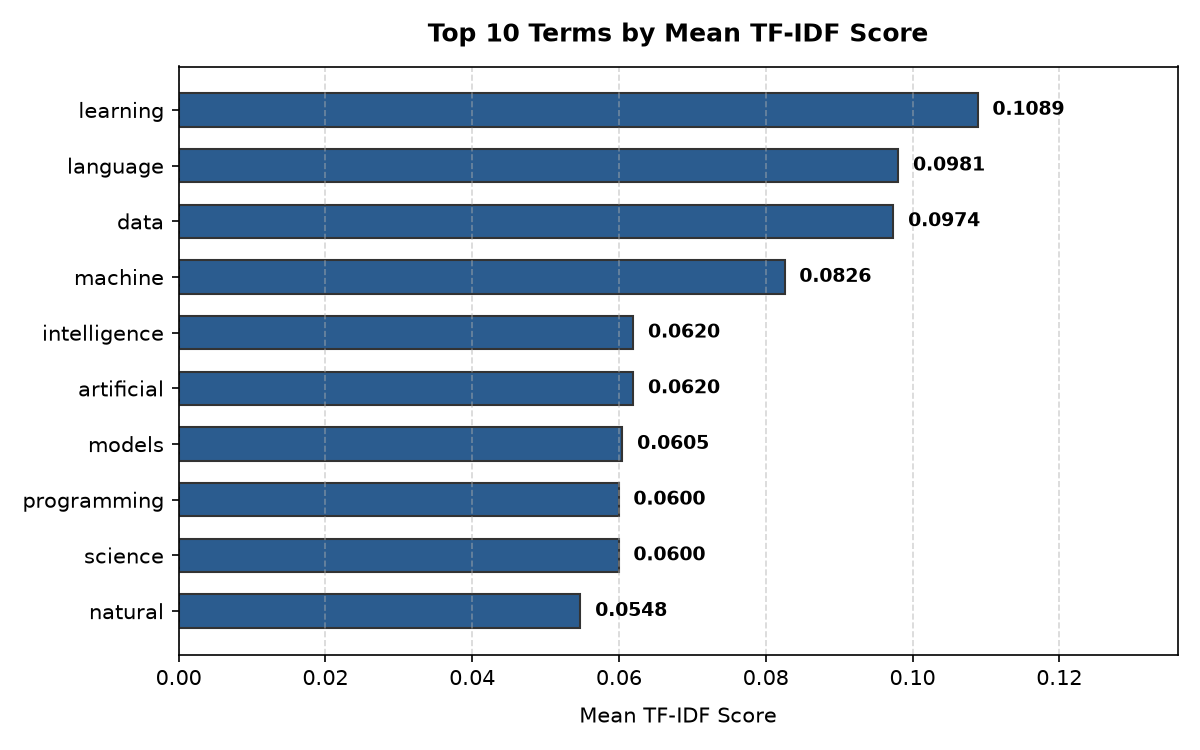

In [10]:
# Calculate mean TF-IDF score per term across the corpus
mean_tfidf = tfidf_df.mean(axis=0).sort_values(ascending=False)
top10_terms = mean_tfidf.head(10)

plt.figure(figsize=(8, 4.8), dpi=150)
y_pos = np.arange(len(top10_terms))
terms = list(top10_terms.index)[::-1]
scores = list(top10_terms.values)[::-1]

bars = plt.barh(y_pos, scores, color="#2b5c8f", edgecolor="#333333", height=0.6)
plt.yticks(y_pos, terms, fontsize=10)
plt.xlabel("Mean TF-IDF Score", fontsize=10, labelpad=8)
plt.title("Top 10 Terms by Mean TF-IDF Score", fontsize=12, fontweight="bold", pad=12)
plt.xlim(0, max(scores) * 1.25)
plt.grid(axis="x", linestyle="--", alpha=0.5)

for bar, score in zip(bars, scores):
    width = bar.get_width()
    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height() / 2.0,
        f"{score:.4f}",
        ha="left", va="center", fontsize=9, fontweight="bold"
    )

plt.tight_layout()
plt.show()


## 10. Results and Observations

Key quantitative metrics and data characteristics derived dynamically from the dataset and vectorization process:


In [11]:
top_term = top10_terms.index[0]
top_score = top10_terms.values[0]
runner_up_term = top10_terms.index[1]
runner_up_score = top10_terms.values[1]

orig_total_words = sum(len(t) for t in df["tokens"])
clean_total_words = sum(len(t) for t in df["filtered_tokens"])
reduction_pct = ((orig_total_words - clean_total_words) / orig_total_words) * 100

print("=" * 65)
print("RESULTS AND OBSERVATIONS (DYNAMICALLY COMPUTED)")
print("=" * 65)
print(f"1. Top TF-IDF Term: '{top_term}' achieved the highest mean score of {top_score:.4f}, followed by '{runner_up_term}' ({runner_up_score:.4f}).")
print(f"2. Stopword Filtering: Reduced total corpus words from {orig_total_words} to {clean_total_words} tokens ({reduction_pct:.1f}% reduction in non-informative words).")
print(f"3. Vocabulary Size: The vectorizer identified {len(feature_names)} unique terms across all {len(df)} documents.")
print(f"4. Matrix Dimensions: Produced an exact {tfidf_df.shape[0]}x{tfidf_df.shape[1]} feature matrix with zero missing values.")
print(f"5. Term Specificity: Domain-specific terms like '{top_term}', '{runner_up_term}', and '{top10_terms.index[2]}' carry the highest weights because they define document topics.")
print("=" * 65)


RESULTS AND OBSERVATIONS (DYNAMICALLY COMPUTED)
1. Top TF-IDF Term: 'learning' achieved the highest mean score of 0.1089, followed by 'language' (0.0981).
2. Stopword Filtering: Reduced total corpus words from 118 to 82 tokens (30.5% reduction in non-informative words).
3. Vocabulary Size: The vectorizer identified 63 unique terms across all 12 documents.
4. Matrix Dimensions: Produced an exact 12x63 feature matrix with zero missing values.
5. Term Specificity: Domain-specific terms like 'learning', 'language', and 'data' carry the highest weights because they define document topics.


## 11. Conclusion

The end-to-end Natural Language Processing workflow implemented in this study establishes the standard methodology for converting raw human language into structured numerical features:

```text
Original Text
    ↓
Lowercasing
    ↓
Tokenization
    ↓
Stopword Removal
    ↓
TF-IDF Vectorization
    ↓
Numerical Feature Matrix
    ↓
Term Analysis and Visualization
```

Text preprocessing serves as a foundational bridge between raw language and machine learning algorithms. By normalizing casing, tokenizing linguistic units, and filtering non-informative stopwords, the vocabulary space is streamlined. Subsequent TF-IDF vectorization assigns mathematically grounded weights that penalize generic high-frequency words while boosting domain-discriminative terms, producing a feature matrix suitable for downstream classification, clustering, and predictive modeling.
